# Part 2 — The First Training Lesson: A Walkthrough

## Coaching a student, the simplest version 🎓

In Part 1 we built the student's *brain* — the Transformer block. But a fresh brain knows nothing. Part 2 is its **first, simplest lesson**: we teach it one little game — *guess the next character* — and watch it actually learn. It's the same "coaching a student" idea that Part 4 will do for real; here everything is kept tiny and visible so you can see each move.

| Coaching a student | Part 2 step |
|---|---|
| turn the page into something readable | **byte tokenizer** (2.1) |
| flashcards: "what comes next?" | **dataset + label shift** (2.2) |
| the student makes a guess | **GPT forward pass** (2.3) |
| grade the guess, make one small correction | **loss + one training step** (2.4) |
| let the student write on its own | **sampling** (2.5) |
| save the student's progress | **checkpoints + eval** (2.6) |

We keep the same sentence from Part 1 — **"I love deep learning"** — so the ideas feel connected, then peek at the real data files (`tiny.txt`, `tiny_hi.txt`) to see what changes at full size.

**Tiny trace settings used in this notebook:**

| Symbol | Value | Meaning |
|---|---:|---|
| `B` | 2 | batch size: two independent training examples |
| `T` | 8 | block size: eight byte tokens per example |
| `vocab_size` | 256 | one class for every possible byte |
| `n_embd` | 6 | model width, matching Part 1's tiny examples |
| `n_head` | 2 | two attention heads |
| `d_head` | 3 | each head sees three features because `6 / 2 = 3` |
| `n_layer` | 1 | one Transformer block for a quick trace |



## 0. Cross-Part Map

This course is a chain. Part 2 is important because it creates the first complete training artifact: a checkpoint from a causal language model.

```mermaid
graph LR
    p1["Part 1<br>Transformer block<br>attention + FFN + residuals"]
    p2["Part 2<br>Tiny LLM training<br>tokens + loss + checkpoints"]
    p3["Part 3<br>Modern architecture<br>RMSNorm + RoPE + KV cache"]
    p4["Part 4<br>Scaling up<br>BPE + AMP + schedules + logging"]
    p6["Part 6<br>SFT<br>instruction data + masked labels"]
    p7["Part 7<br>Reward model<br>preference pairs -> scalar reward"]
    p8["Part 8<br>PPO RLHF<br>policy + value + reward"]
    p9["Part 9<br>GRPO RLHF<br>group-relative rewards"]

    p1 --> p2 --> p3 --> p4
    p4 --> p6
    p4 --> p7
    p6 --> p8
    p7 --> p8
    p6 --> p9
    p7 --> p9

    style p1 fill:#e8e8e8,stroke:#bbb,color:#777
    style p2 fill:#d6eaf8,stroke:#2874a6,stroke-width:3px,color:#000
    style p3 fill:#e8daef,stroke:#6c3483,color:#000
    style p4 fill:#d4edda,stroke:#28a745,color:#000
    style p6 fill:#fff3c4,stroke:#b38600,color:#000
    style p7 fill:#fdebd0,stroke:#b35900,color:#000
    style p8 fill:#fdd,stroke:#c33,color:#000
    style p9 fill:#fdd,stroke:#c33,color:#000
```

| Bridge | Meaning |
|---|---|
| **Part 1 memory** | We already know how a Transformer block transforms `(B, T, d_model)` tensors. |
| **Part 2 now** | We learn where those tensors come from, how loss is computed, and how weights change. |
| **Returns later** | Later parts keep the same skeleton but replace pieces: tokenizer, architecture, training loop, or objective. |



## Setup

Run the notebook from inside `part_2/`. The cell below makes local imports work even if Jupyter starts from a different folder.



In [1]:
from pathlib import Path
import math
import sys
import torch
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt

PART2 = Path.cwd()
if PART2.name != "part_2":
    candidate = Path(r"C:\Home\Projects\DataScienceLearningProjects\15. Build LLM From Scratch\part_2")
    if candidate.exists():
        PART2 = candidate
sys.path.insert(0, str(PART2))

from tokenizer import ByteTokenizer
from dataset import ByteDataset
from model_gpt import GPT
from utils import top_k_top_p_filtering

torch.manual_seed(7)
print("Part 2 path:", PART2)
print("PyTorch:", torch.__version__)



Part 2 path: c:\Home\Projects\DataScienceLearningProjects\15. Build LLM From Scratch\part_2
PyTorch: 2.10.0+cpu


## 2.1 Byte Tokenizer

> **Part 1 memory:** Part 1 started after tokenization, with vectors shaped `(B, T, d_model)`.
>
> **Part 2 now:** we start earlier: raw text becomes integer token IDs, then embeddings turn IDs into vectors.
>
> **Returns later:** Part 4 replaces byte tokenization with BPE, but the model still receives integer IDs shaped `(B, T)`.

A tokenizer answers one very practical question:

**How do we turn text into numbers the student can actually work with?**

A model can't read letters — only numbers. So the first move of every lesson is to chop the text into pieces and give each piece an ID. Part 2 uses the simplest possible chopping: **one ID per byte**. Since every byte is already a number from 0 to 255, the vocabulary is exactly 256 — no training, no rules, no vocabulary file. (Part 4 upgrades this to smarter, chunkier pieces; here we stay dead simple so you can see every ID.)



In [2]:
tok = ByteTokenizer()
anchor = "I love deep learning"
ids = tok.encode(anchor)

rows = []
for i, token_id in enumerate(ids.tolist()):
    b = bytes([token_id])
    rows.append({
        "position": i,
        "byte token id": token_id,
        "byte as hex": f"0x{token_id:02x}",
        "character if printable": b.decode("utf-8", errors="ignore") or "(continuation byte)",
    })
pd.DataFrame(rows)



,position,byte token id,byte as hex,character if printable
0,0,73,0x49,I
1,1,32,0x20,
2,2,108,0x6c,l
3,3,111,0x6f,o
4,4,118,0x76,v
5,5,101,0x65,e
6,6,32,0x20,
7,7,100,0x64,d
8,8,101,0x65,e
9,9,101,0x65,e


### What just happened?

The sentence has 20 characters and, because it is plain ASCII, it also has 20 bytes. So here every visible character corresponds to exactly one token ID.

For the first few positions:

| text position | character | byte token ID |
|---:|---|---:|
| 0 | `I` | 73 |
| 1 | space | 32 |
| 2 | `l` | 108 |
| 3 | `o` | 111 |

The model never sees the letter `I` directly. It sees the integer `73`, then `nn.Embedding(256, n_embd)` looks up row 73 in a trainable table.



In [3]:
roundtrip = tok.decode(ids)
print("original: ", anchor)
print("ids:      ", ids.tolist())
print("decoded:  ", roundtrip)
print("vocab size:", tok.vocab_size)



original:  I love deep learning
ids:       [73, 32, 108, 111, 118, 101, 32, 100, 101, 101, 112, 32, 108, 101, 97, 114, 110, 105, 110, 103]
decoded:   I love deep learning
vocab size: 256


### Unicode note: bytes are not always characters

`tiny_hi.txt` contains Hindi text. UTF-8 represents many non-English characters using multiple bytes. That is why byte-level tokenization is universal but not always compact.



In [4]:
hi_text = (PART2 / "tiny_hi.txt").read_text(encoding="utf-8")
hi_snippet = hi_text.splitlines()[1][:12]
hi_ids = tok.encode(hi_snippet)

print("snippet:", hi_snippet)
print("characters:", len(hi_snippet))
print("byte tokens:", len(hi_ids))
print("first 30 byte IDs:", hi_ids[:30].tolist())
print("decoded again:", tok.decode(hi_ids))



snippet: जो सुमिरत सि
characters: 12
byte tokens: 32
first 30 byte IDs: [224, 164, 156, 224, 165, 139, 32, 224, 164, 184, 224, 165, 129, 224, 164, 174, 224, 164, 191, 224, 164, 176, 224, 164, 164, 32, 224, 164, 184, 224]
decoded again: जो सुमिरत सि


## 2.2 Dataset + Label Shift

> **Part 1 memory:** the Transformer block reads a sequence of token vectors in parallel.
>
> **Part 2 now:** the dataset creates many short token sequences and the matching next-token labels.
>
> **Returns later:** Part 4 keeps this x/y shift with BPE IDs; Part 6 keeps causal LM labels but masks prompt tokens during SFT.

The whole lesson is one little game: **guess the next character.** We make flashcards out of the text automatically — the front of a card is a short run of characters, and the back is *the same run shifted over by one*, because the answer to "what's next?" is always just the following character.

If the front of the card is:

```text
I love d
```

then the back (the answers) is the same text moved one step later:

```text
 love de
```

So at each spot `t`, the student sees `x[t]` and tries to name `y[t] = x[t+1]`. One short card is really many tiny quizzes at once.



In [5]:
block_size = 8
anchor_ids = tok.encode(anchor)
x_one = anchor_ids[:block_size]
y_one = anchor_ids[1:block_size + 1]

shift_rows = []
for t in range(block_size):
    x_id = int(x_one[t])
    y_id = int(y_one[t])
    shift_rows.append({
        "t": t,
        "x[t] id": x_id,
        "x[t] char": bytes([x_id]).decode("utf-8", errors="ignore") or "?",
        "predict y[t] id": y_id,
        "predict y[t] char": bytes([y_id]).decode("utf-8", errors="ignore") or "?",
    })
pd.DataFrame(shift_rows)



,t,x[t] id,x[t] char,predict y[t] id,predict y[t] char
0,0,73,I,32,
1,1,32,,108,l
2,2,108,l,111,o
3,3,111,o,118,v
4,4,118,v,101,e
5,5,101,e,32,
6,6,32,,100,d
7,7,100,d,101,e


### The key alignment

Look at row `t=0`: the model receives byte `73` (`I`) and the correct answer is byte `32` (space). At `t=1`, it receives the space and the correct answer is `108` (`l`).

This is the central training signal for a causal language model:

```text
current token/context -> predict the next token
```

It is small, almost silly-looking, and it scales all the way to GPT-style pretraining.



In [6]:
# Build a tiny in-memory demonstration batch from the anchor sentence.
# This mirrors ByteDataset.get_batch, but keeps the example deterministic.
x = torch.stack([
    anchor_ids[0:0 + block_size],
    anchor_ids[5:5 + block_size],
])
y = torch.stack([
    anchor_ids[1:1 + block_size],
    anchor_ids[6:6 + block_size],
])

print("x shape:", tuple(x.shape))
print("y shape:", tuple(y.shape))
print("x[0]:", x[0].tolist(), "->", tok.decode(x[0]))
print("y[0]:", y[0].tolist(), "->", tok.decode(y[0]))
print("shift check:", bool((y[:, :-1] == x[:, 1:]).all()))



x shape: (2, 8)
y shape: (2, 8)
x[0]: [73, 32, 108, 111, 118, 101, 32, 100] -> I love d
y[0]: [32, 108, 111, 118, 101, 32, 100, 101] ->  love de
shift check: True


In [7]:
# The actual dataset class does the same thing, but samples random windows
# from a real text file and returns tensors on the requested device.
ds = ByteDataset(str(PART2 / "tiny.txt"), block_size=block_size)
xb, yb = ds.get_batch("train", batch_size=2, device=torch.device("cpu"))
print("xb shape:", tuple(xb.shape))
print("yb shape:", tuple(yb.shape))
print("xb[0] decoded:", repr(tok.decode(xb[0])))
print("yb[0] decoded:", repr(tok.decode(yb[0])))
print("dataset shift check:", bool((yb[:, :-1] == xb[:, 1:]).all()))



xb shape: (2, 8)
yb shape: (2, 8)
xb[0] decoded: ' God of '
yb[0] decoded: 'God of H'
dataset shift check: True


## 2.3 GPT Forward Pass

> **Part 1 memory:** a Transformer block transforms `(B, T, d_model)` into `(B, T, d_model)`.
>
> **Part 2 now:** `GPT` wraps that block with token embeddings before it and a vocabulary head after it.
>
> **Returns later:** Part 3 swaps the internals; Part 4 scales the same interface; Parts 6-9 keep calling policy models with token IDs.

Here is the complete forward path:

```mermaid
graph TD
    ids["token IDs<br>(B, T)"]
    tokemb["token embedding<br>nn.Embedding(256, n_embd)<br>(B, T, n_embd)"]
    posemb["position embedding<br>nn.Embedding(block_size, n_embd)<br>(1, T, n_embd)"]
    add["add token + position<br>(B, T, n_embd)"]
    block["Transformer block from Part 1<br>LN -> causal MHA -> residual -> LN -> FFN -> residual"]
    lnf["final LayerNorm<br>(B, T, n_embd)"]
    head["LM head<br>Linear(n_embd, 256)<br>(B, T, 256)"]

    ids --> tokemb --> add
    posemb --> add
    add --> block --> lnf --> head

    style ids fill:#d6eaf8,stroke:#2874a6,color:#000
    style tokemb fill:#d4edda,stroke:#28a745,color:#000
    style posemb fill:#d4edda,stroke:#28a745,color:#000
    style add fill:#fff3c4,stroke:#b38600,color:#000
    style block fill:#fdebd0,stroke:#b35900,color:#000
    style lnf fill:#e8daef,stroke:#6c3483,color:#000
    style head fill:#fdd,stroke:#c33,color:#000
```

The output has 256 numbers per position because this model predicts one of 256 byte tokens.



In [8]:
model = GPT(vocab_size=256, block_size=block_size, n_layer=1, n_head=2, n_embd=6, dropout=0.0)
model.eval()

with torch.no_grad():
    logits, loss = model(x, y)

print("x shape:      ", tuple(x.shape), "= (B, T)")
print("logits shape: ", tuple(logits.shape), "= (B, T, vocab_size)")
print("loss:         ", float(loss))



x shape:       (2, 8) = (B, T)
logits shape:  (2, 8, 256) = (B, T, vocab_size)
loss:          5.551368236541748


### Shape trace inside the model

| Stage | Shape | Meaning |
|---|---|---|
| `idx` | `(B=2, T=8)` | byte token IDs |
| `tok_emb(idx)` | `(2, 8, 6)` | learned vector for each byte |
| `pos_emb(pos)` | `(1, 8, 6)` | learned vector for each position, broadcast over batch |
| `x` after add | `(2, 8, 6)` | content plus position |
| attention `q,k,v` | `(2, 2, 8, 3)` | two heads, each with `d_head=3` |
| block output | `(2, 8, 6)` | same width, so blocks can stack |
| logits | `(2, 8, 256)` | one score per byte token at every position |

Notice the Part 1 contract: the block starts and ends with the same width `(B, T, n_embd)`. That is what lets Part 2 stack blocks and attach a vocabulary head.



In [9]:
# Let's inspect one position's prediction problem.
b, t = 0, 0
one_logits = logits[b, t]
target_id = int(y[b, t])
probs = torch.softmax(one_logits, dim=-1)

print("At batch", b, "position", t)
print("input byte:", int(x[b, t]), repr(tok.decode([int(x[b, t])])))
print("target next byte:", target_id, repr(tok.decode([target_id])))
print("probability assigned to target:", float(probs[target_id]))
print("negative log likelihood:", float(-torch.log(probs[target_id])))



At batch 0 position 0
input byte: 73 'I'
target next byte: 32 ' '
probability assigned to target: 0.0040048654191195965
negative log likelihood: 5.52024507522583


## 2.4 Cross-Entropy + One Training Step

> **Part 1 memory:** gradients update the matrices inside attention and FFN, but Part 1 mostly inspected forward math.
>
> **Part 2 now:** we compute a scalar loss and use backprop to move every parameter a little.
>
> **Returns later:** Part 4 makes this loop production-shaped; Part 6 changes which labels count; Parts 8-9 replace plain CE with RL objectives.

Now we **grade** the guess. The score we use (cross-entropy) is really just:

```text
loss = how surprised the student was by the correct answer
```

If the student gave the right next character a high probability, the surprise (loss) is low; if it was confident and wrong, the surprise is high. Training nudges the weights to be less surprised next time.

For a batch, PyTorch lines up every spot on every card into one big stack of little quizzes and grades them together:

```text
guesses: (B, T, 256) -> (B*T, 256)
answers: (B, T)      -> (B*T)
```



In [10]:
manual_loss = F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1))
print("model loss: ", float(loss))
print("manual loss:", float(manual_loss))
print("same value: ", torch.allclose(loss, manual_loss))



model loss:  5.551368236541748
manual loss: 5.551368236541748
same value:  True


### One optimizer step

This is the smallest meaningful training loop:

1. Run the model: `logits, loss = model(x, y)`.
2. Clear old gradients: `optimizer.zero_grad(...)`.
3. Backpropagate: `loss.backward()`.
4. Update weights: `optimizer.step()`.

Before training, the model is basically guessing across 256 bytes, so the loss is near `log(256) ~= 5.545`. After many updates, the model should assign more probability to plausible next bytes, so loss should go down.



In [11]:
torch.manual_seed(7)
train_model = GPT(vocab_size=256, block_size=block_size, n_layer=1, n_head=2, n_embd=6, dropout=0.0)
opt = torch.optim.AdamW(train_model.parameters(), lr=1e-2)

logits_before, loss_before = train_model(x, y)
first_weight_before = train_model.tok_emb.weight[73, 0].item()

opt.zero_grad(set_to_none=True)
loss_before.backward()
opt.step()

logits_after, loss_after = train_model(x, y)
first_weight_after = train_model.tok_emb.weight[73, 0].item()

print("loss before one update:", float(loss_before))
print("loss after one update: ", float(loss_after))
print("embedding row 73, dim 0 before:", first_weight_before)
print("embedding row 73, dim 0 after: ", first_weight_after)
print("weight changed:", first_weight_before != first_weight_after)



loss before one update: 5.569803714752197
loss after one update:  5.46388578414917
embedding row 73, dim 0 before: 0.024211937561631203
embedding row 73, dim 0 after:  0.03420950472354889
weight changed: True


C:\Users\MSI\AppData\Local\Temp\ipykernel_11176\3935725961.py:15: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  print("loss before one update:", float(loss_before))


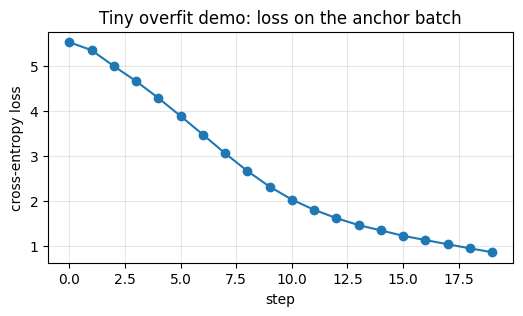

first loss: 5.519296169281006 last loss: 0.8619918823242188


In [12]:
# A very tiny training demo. This intentionally trains only on the anchor batch,
# so it is fast and easy to inspect. The script train.py does the same pattern
# on real dataset batches and periodically saves checkpoints.
tiny_model = GPT(vocab_size=256, block_size=block_size, n_layer=1, n_head=2, n_embd=6, dropout=0.0)
tiny_opt = torch.optim.AdamW(tiny_model.parameters(), lr=3e-2)
losses = []
for step in range(20):
    _, tiny_loss = tiny_model(x, y)
    tiny_opt.zero_grad(set_to_none=True)
    tiny_loss.backward()
    torch.nn.utils.clip_grad_norm_(tiny_model.parameters(), 1.0)
    tiny_opt.step()
    losses.append(float(tiny_loss))

plt.figure(figsize=(6, 3))
plt.plot(losses, marker="o")
plt.title("Tiny overfit demo: loss on the anchor batch")
plt.xlabel("step")
plt.ylabel("cross-entropy loss")
plt.grid(True, alpha=0.3)
plt.show()
print("first loss:", losses[0], "last loss:", losses[-1])



## 2.5 Sampling: Temperature, Top-k, Top-p

> **Part 1 memory:** a forward pass computes contextual features.
>
> **Part 2 now:** generation repeats forward passes, choosing one next token at a time.
>
> **Returns later:** SFT, PPO, and GRPO all sample from a policy model with the same basic autoregressive loop.

Now the **exam**: let the student write on its own. After training, the model gives a score for every possible next character, and sampling turns those scores into actual text, one character at a time:

```text
what's written so far -> scores for the next byte -> filter -> pick one -> add it -> repeat
```

The three dials that control *how* it picks:

| Dial | What it does | In plain terms |
|---|---|---|
| `temperature` | softens or sharpens the scores | low = plays it safe, high = gets adventurous |
| `top_k` | keep only the `k` best options | ignore the long tail of unlikely characters |
| `top_p` | keep the smallest set of options covering `p` of the probability | a shortlist that grows/shrinks with confidence |



In [13]:
# Toy logits over five possible next tokens, just for visualization.
toy_labels = ["space", "e", "a", "z", "newline"]
toy_logits = torch.tensor([[3.0, 2.2, 1.1, 0.2, -0.4]])

def probs_after(logits):
    return torch.softmax(logits, dim=-1).squeeze(0)

base_probs = probs_after(toy_logits)
cool_probs = probs_after(toy_logits / 0.5)
hot_probs = probs_after(toy_logits / 1.8)
topk_logits = top_k_top_p_filtering(toy_logits, top_k=2)
topk_probs = probs_after(topk_logits)
topp_logits = top_k_top_p_filtering(toy_logits, top_p=0.80)
topp_probs = probs_after(topp_logits)

pd.DataFrame({
    "token": toy_labels,
    "base p": base_probs.tolist(),
    "temp=0.5 p": cool_probs.tolist(),
    "temp=1.8 p": hot_probs.tolist(),
    "top_k=2 p": topk_probs.tolist(),
    "top_p=0.80 p": topp_probs.tolist(),
})



,token,base p,temp=0.5 p,temp=1.8 p,top_k=2 p,top_p=0.80 p
0,space,0.590639,0.813617,0.425262,0.689974,1.0
1,e,0.265391,0.164267,0.272670,0.310026,0.0
2,a,0.088341,0.018201,0.147991,0.000000,0.0
3,z,0.035917,0.003009,0.089761,0.000000,0.0
4,newline,0.019712,0.000906,0.064317,0.000000,0.0


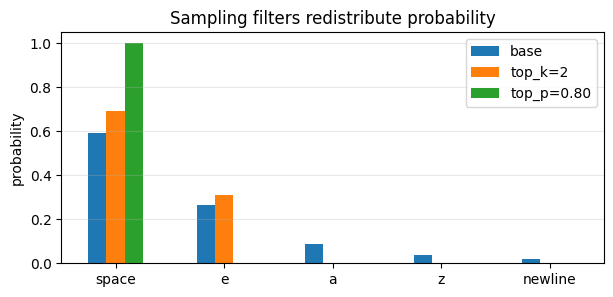

In [14]:
plot_df = pd.DataFrame({
    "base": base_probs.tolist(),
    "top_k=2": topk_probs.tolist(),
    "top_p=0.80": topp_probs.tolist(),
}, index=toy_labels)
plot_df.plot(kind="bar", figsize=(7, 3))
plt.title("Sampling filters redistribute probability")
plt.ylabel("probability")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()



In [15]:
# Generate a few bytes from the tiny overfit model. This is not a good language
# model yet; it is only showing the mechanics of autoregressive sampling.
prompt = tok.encode("I ").unsqueeze(0)
out = tiny_model.generate(prompt, max_new_tokens=24, temperature=0.8, top_k=20, top_p=None)
print(tok.decode(out[0]))



I oveA d e oveee dleeee ep


## 2.6 Checkpoints + Eval

> **Part 1 memory:** tests verified individual math pieces.
>
> **Part 2 now:** checkpoints preserve learned weights, and validation loss measures whether the model predicts held-out text.
>
> **Returns later:** Part 4 makes checkpointing/resume robust; Part 6 loads pretrained checkpoints for SFT; Parts 8-9 load SFT and reward checkpoints.

A checkpoint is a **save point** — a snapshot of everything the student has learned, so a crash or a stop doesn't throw away hours of practice:

```python
{
    "model": model.state_dict(),     # the learned weights
    "config": {                       # the model's blueprint
        "vocab_size": 256, "block_size": ..., "n_layer": ...,
        "n_head": ..., "n_embd": ..., "dropout": ...,
    },
}
```

The `config` matters because the weights only fit the exact shape they were trained in — a `(256, 6)` table can't drop into a model expecting `(256, 128)`. (Part 4 makes this save/resume fully robust; here it's just the basic idea.)



In [16]:
ckpt = {
    "model": tiny_model.state_dict(),
    "config": {
        "vocab_size": 256,
        "block_size": block_size,
        "n_layer": 1,
        "n_head": 2,
        "n_embd": 6,
        "dropout": 0.0,
    },
}
print("checkpoint top-level keys:", list(ckpt.keys()))
print("config:", ckpt["config"])
print("number of tensors in state_dict:", len(ckpt["model"]))
print("example tensor:", next(iter(ckpt["model"].items()))[0], tuple(next(iter(ckpt["model"].items()))[1].shape))



checkpoint top-level keys: ['model', 'config']
config: {'vocab_size': 256, 'block_size': 8, 'n_layer': 1, 'n_head': 2, 'n_embd': 6, 'dropout': 0.0}
number of tensors in state_dict: 15
example tensor: tok_emb.weight (256, 6)


In [17]:
# Eval loss: same cross-entropy computation, but no gradients and model.eval().
tiny_model.eval()
with torch.no_grad():
    _, eval_loss = tiny_model(x, y)
print("eval loss on anchor batch:", float(eval_loss))



eval loss on anchor batch: 0.7753234505653381


### Why `model_best.pt` exists

During real training, loss jumps around. The latest checkpoint is not always the best checkpoint. `train.py` saves `model_best.pt` when validation loss improves, so later scripts can load the strongest version seen so far.

```mermaid
graph TD
    train["train.py<br>updates model weights"]
    val["estimate_loss<br>train + val batches"]
    better{"val loss improved?"}
    best["save model_best.pt"]
    final["save model_final.pt<br>at the end"]
    sample["sample.py<br>generate text"]
    eval["eval_loss.py<br>measure val loss"]
    future["later parts<br>SFT / RM / PPO / GRPO"]

    train --> val --> better
    better -->|yes| best
    better -->|no| train
    train --> final
    best --> sample
    best --> eval
    best --> future

    style train fill:#d6eaf8,stroke:#2874a6,color:#000
    style val fill:#fff3c4,stroke:#b38600,color:#000
    style better fill:#fdebd0,stroke:#b35900,color:#000
    style best fill:#d4edda,stroke:#28a745,color:#000
    style final fill:#e8e8e8,stroke:#bbb,color:#777
    style sample fill:#e8daef,stroke:#6c3483,color:#000
    style eval fill:#e8daef,stroke:#6c3483,color:#000
    style future fill:#fdd,stroke:#c33,color:#000
```



## Final Recap: The Full Part 2 Pipeline

```mermaid
graph TD
    raw["raw text<br>tiny.txt / prompt"]
    bytes["UTF-8 bytes<br>token IDs 0..255"]
    batch["dataset windows<br>x and shifted y"]
    emb["token + position embeddings<br>(B, T, n_embd)"]
    block["Part 1 Transformer block<br>causal attention + FFN"]
    logits["LM head logits<br>(B, T, 256)"]
    loss["cross-entropy loss<br>predict y from x"]
    opt["AdamW update<br>change parameters"]
    ckpt["checkpoint<br>model_best.pt"]
    gen["sampling<br>new byte tokens -> text"]

    raw --> bytes --> batch --> emb --> block --> logits --> loss --> opt --> ckpt --> gen
    logits --> gen

    style raw fill:#d6eaf8,stroke:#2874a6,color:#000
    style bytes fill:#d4edda,stroke:#28a745,color:#000
    style batch fill:#fff3c4,stroke:#b38600,color:#000
    style emb fill:#d4edda,stroke:#28a745,color:#000
    style block fill:#fdebd0,stroke:#b35900,color:#000
    style logits fill:#e8daef,stroke:#6c3483,color:#000
    style loss fill:#fdd,stroke:#c33,color:#000
    style opt fill:#fff3c4,stroke:#b38600,color:#000
    style ckpt fill:#d4edda,stroke:#28a745,color:#000
    style gen fill:#d6eaf8,stroke:#2874a6,color:#000
```

### What Part 2 gives us

1. **A tokenizer contract:** text becomes integer IDs.
2. **A dataset contract:** `x` is current tokens, `y` is next tokens.
3. **A model contract:** `GPT(idx, targets)` returns `(logits, loss)`.
4. **A training contract:** loss -> gradients -> AdamW update.
5. **A generation contract:** logits -> filters -> sample -> append.
6. **A checkpoint contract:** learned weights and config can be saved and loaded.

### Where each idea returns later

| Part 2 idea | Returns later as |
|---|---|
| Byte tokenizer | Part 4 BPE tokenizer |
| Learned absolute position embedding | Part 3 RoPE |
| LayerNorm + GELU FFN | Part 3 RMSNorm + SwiGLU |
| Plain causal attention | Part 3 attention with KV cache / sliding windows |
| Simple training loop | Part 4 gradient accumulation, AMP, schedules, logging |
| Cross-entropy next-token loss | Part 6 masked SFT loss |
| Checkpoints | Parts 6-9 load pretrained, SFT, and reward models |
| Sampling | Parts 8-9 policy rollouts |

If Part 1 was **the student's brain**, Part 2 was its **first lesson** — guess the next character, grade, correct, repeat — plus saving progress and letting it write on its own. Every idea here returns in Part 4, done at full scale. Same game, bigger classroom.

